## Часть 1

In [18]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

### Описательные статистики
Источник данных: https://tochno.st/datasets/regions_collection - социально-экономические показатели регионов России.

In [2]:
economics_df = pd.read_csv("data/data_regions_collection_102_v20250605.csv", sep=";")

Группировка данных оборота розничной торговли организаций потребительской кооперации по регионам:

In [3]:
consumption = economics_df[(economics_df["section"] == "Потребительский рынок")
           & (economics_df["subsection"] == "Млн руб.")
           & (economics_df["object_level"] == "регион")][["object_name", "indicator_value"]]
consumption_grouped = consumption.groupby("object_name")["indicator_value"].mean()
consumption_grouped = consumption_grouped[consumption_grouped > 0.0] # удаление выбросов (отрицательных значений)

Основные статистики:

In [4]:
pd.DataFrame(consumption_grouped).describe()

,indicator_value
count,80.000000
mean,1473.622500
std,1719.594953
min,4.700000
25%,280.950000
50%,790.100000
75%,2257.025000
max,8101.600000


In [5]:
consumption_grouped[(consumption_grouped == min(consumption_grouped))
                  | (consumption_grouped == max(consumption_grouped))]

object_name
Вологодская область             8101.6
Еврейская автономная область       4.7
Name: indicator_value, dtype: float64

* В наборе представлены данные c 80 регионов.

* Средний размер годового оборота розничной торговли равен 1 млрд. 473 млн. руб.

* Минимальный годовой оборот зафиксирован в Еврейской автономной области (4.7 млн. руб.)

* Максимальный -- в Вологодской области (8 млрд. 101 млн 600 тыс. руб)

* В половине регионов РФ годовой оборот не превышает 790 млн. руб.

In [17]:
variation = stats.tvar(consumption_grouped) # дисперсия
skewness = stats.skew(consumption_grouped) # ассиметрия
kurtosis = stats.kurtosis(consumption_grouped) # эксцесс

print(f"""
    Дисперсия: {variation} млн. руб.
    Коэффициент асимметрии: {round(skewness, 3)}
    Эксцесс: {round(kurtosis, 3)}""")


    Дисперсия: 2957006.801512658 млн. руб.
    Коэффициент асимметрии: 1.734
    Эксцесс: 2.725


Коэффициент ассиметрии > 0 -- правосторонняя асимметрия

Коэффициент эксцесса > 0 -- распределение островершинное

### Законы распределения

#### Распределение Фишера

In [106]:
ps = [0.9, 0.95, 0.99]

In [118]:
def draw_plot(x, df1, df2, pdf, cdf, axe, row):

    # График плотности (PDF)
    axe[row, 0].plot(x, pdf, 'r-', lw=2)
    axe[row, 0].set_title(f'({df1}, {df2})')
    axe[row, 0].grid(True, alpha=0.3)

    # График функции распределения (CDF)
    axe[row, 1].plot(x, cdf, 'b-', lw=2)
    axe[row, 1].set_title(f'({df1}, {df2})')
    axe[row, 1].grid(True, alpha=0.3)

p-value: 2.3226039408913097 df1=10 df2=10
p-value: 2.9782370160823213 df1=10 df2=10
p-value: 4.849146802080026 df1=10 df2=10
p-value: 2.4119549035796255 df1=2 df2=50
p-value: 3.1826098520427744 df1=2 df2=50
p-value: 5.056610865435323 df1=2 df2=50
p-value: 1.729149566795462 df1=10 df2=50
p-value: 2.026142961171105 df1=10 df2=50
p-value: 2.6981394137863823 df1=10 df2=50
p-value: 1.6115128098251394 df1=10 df2=500
p-value: 1.8496372402604002 df1=10 df2=500
p-value: 2.3564550184305264 df1=10 df2=500
p-value: 1.3500731526602419 df1=30 df2=1000
p-value: 1.4705935071882208 df1=30 df2=1000
p-value: 1.7158441612092474 df1=30 df2=1000


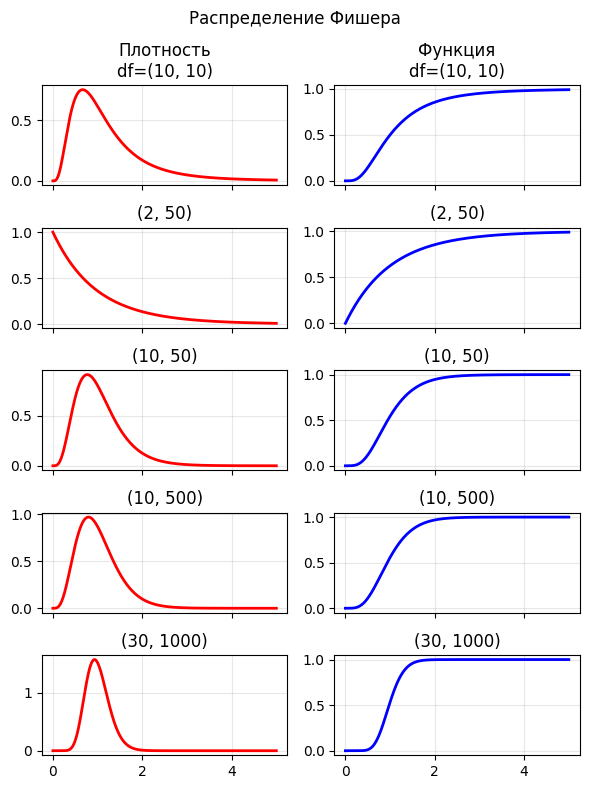

In [110]:
from scipy.stats import f

x = np.linspace(0, 5, 500)

dfs = [(10, 10), (2, 50), (10, 50), (10, 500), (30, 1000)]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8), sharex=True)
row_num = 0
for df1, df2 in dfs:
    pdf = f.pdf(x, df1, df2) # Плотность вероятности
    cdf = f.cdf(x, df1, df2) # Функция распределения
    draw_plot(x, df1, df2, pdf, cdf, axes, row_num)
    row_num += 1

    for p in ps:
        print(f"p-value: {f.ppf(p, df1, df2)} при df1={df1} df2={df2}")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Распределение Фишера")
fig.tight_layout()

С увеличением степеней свободы график плотности становится более островершинным, график функции  меняется более резко

#### Распределение Стьюдента

In [66]:
def draw_t_plot(x, df1, pdf, cdf, axe, row):

    axe[row, 0].plot(x, pdf, 'r-', lw=2)
    axe[row, 0].set_title(f'df={df1}')
    axe[row, 0].grid(True, alpha=0.3)

    axe[row, 1].plot(x, cdf, 'b-', lw=2)
    axe[row, 1].set_title(f'df={df1}')
    axe[row, 1].grid(True, alpha=0.3)

p-value: 1.372183641110336 при df1=10
p-value: 1.8124611228116754 при df1=10
p-value: 2.7637694581126957 при df1=10
p-value: 1.2987136941948099 при df1=50
p-value: 1.675905025163097 при df1=50
p-value: 2.4032719166741714 при df1=50
p-value: 1.2857987939948012 при df1=200
p-value: 1.6525081009108769 при df1=200
p-value: 2.3451370822594684 при df1=200


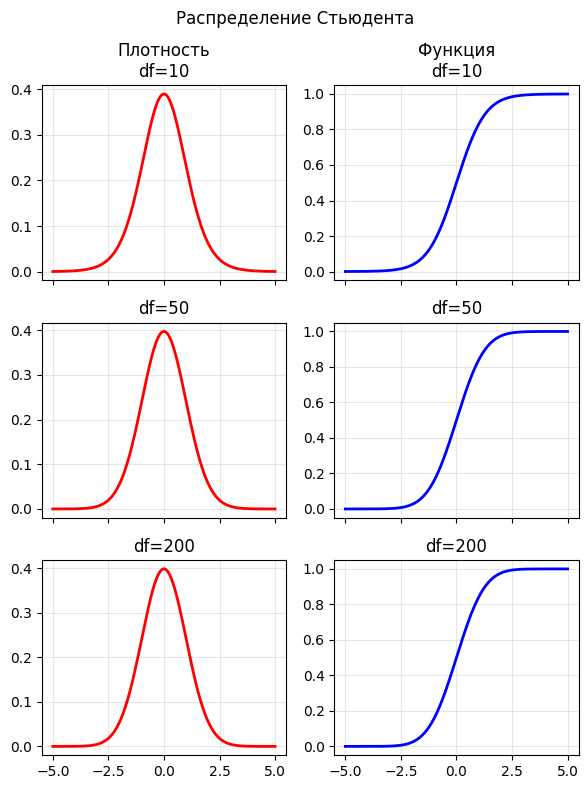

In [111]:
from scipy.stats import t
x = np.linspace(-5, 5, 500)

dfs = [10, 50, 200]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8), sharex=True)
row_num = 0
for df1 in dfs:
    pdf = t.pdf(x, df1) # Плотность вероятности
    cdf = t.cdf(x, df1) # Функция распределения
    draw_t_plot(x, df1, pdf, cdf, axes, row_num)
    row_num += 1

    for p in ps:
        print(f"p-value: {t.ppf(p, df1)} при df1={df1}")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Распределение Стьюдента")
fig.tight_layout()

С увеличением степени свободы хвосты становятся более резкими

#### Показательное распределение

p-value: 2.802585092994046 при lambda=0.5
p-value: 3.49573227355399 при lambda=0.5
p-value: 5.105170185988091 при lambda=0.5
p-value: 7.302585092994046 при lambda=5.0
p-value: 7.99573227355399 при lambda=5.0
p-value: 9.60517018598809 при lambda=5.0
p-value: 22.302585092994047 при lambda=20.0
p-value: 22.99573227355399 при lambda=20.0
p-value: 24.60517018598809 при lambda=20.0


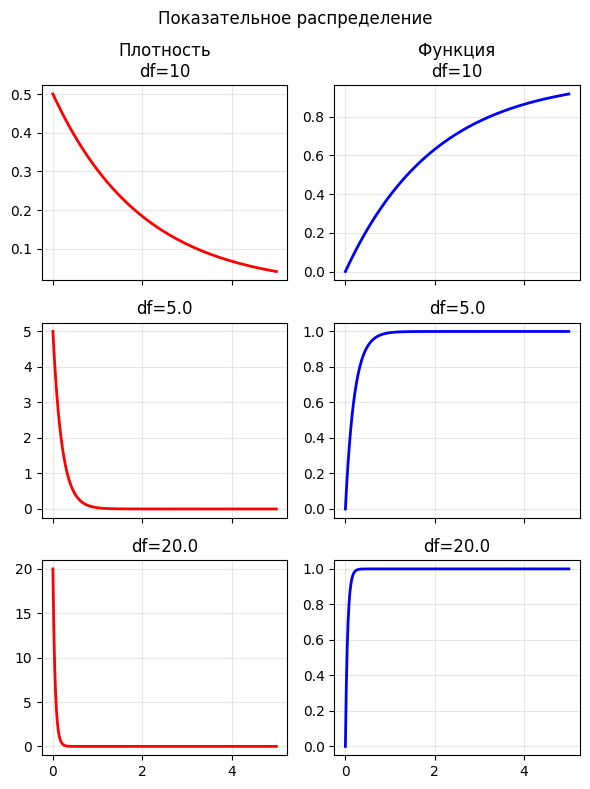

In [112]:
from scipy.stats import expon

x = np.linspace(0, 5, 500)
lambdas = [0.5, 5.0, 20.0]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8), sharex=True)
row_num = 0
for df1 in lambdas:
    pdf = expon.pdf(x, scale=1/df1) # Плотность вероятности
    cdf = expon.cdf(x, scale=1/df1) # Функция распределения
    draw_t_plot(x, df1, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        print(f"p-value: {expon.ppf(p, df1)} при lambda={df1}")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Показательное распределение")
fig.tight_layout()

С увеличением степени свободы графики плотности и функции становится более резким

#### $\chi^2$-распределение

p-value: 15.987179172105265 при df=10
p-value: 18.307038053275146 при df=10
p-value: 23.209251158954356 при df=10
p-value: 63.167121005726315 при df=50
p-value: 67.5048065495412 при df=50
p-value: 76.1538912490127 при df=50
p-value: 226.02104771968897 при df=200
p-value: 233.99426889232492 при df=200
p-value: 249.4451229814416 при df=200


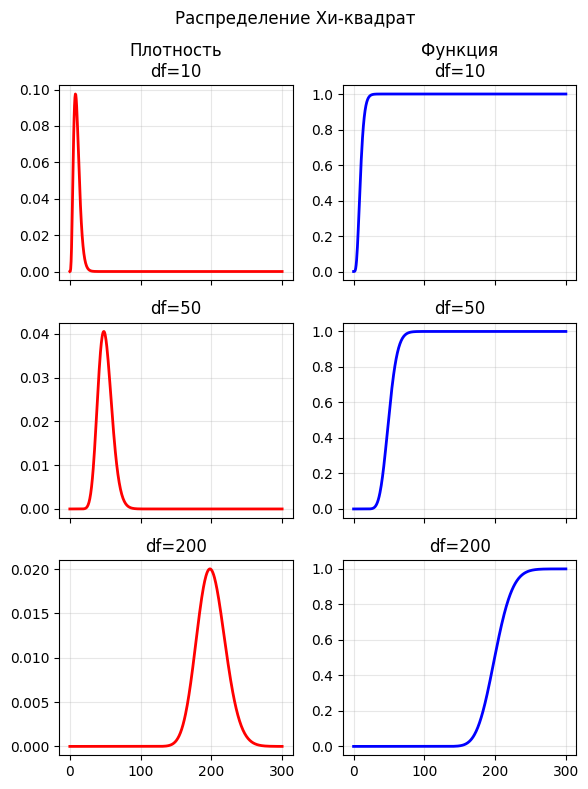

In [113]:
from scipy.stats import chi2
x = np.linspace(0, 300, 500)

dfs = [10, 50, 200]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8), sharex=True)
row_num = 0
for df1 in dfs:
    pdf = chi2.pdf(x, df1) # Плотность вероятности
    cdf = chi2.cdf(x, df1) # Функция распределения
    draw_t_plot(x, df1, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        print(f"p-value: {chi2.ppf(p, df1)} при df={df1}")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Распределение Хи-квадрат")
fig.tight_layout()

С увеличением степени свободы пики графиков смещаются вправо

 #### Логнормальное распределение

p-value: 4.602224479279157 при df1=200
p-value: 6.180251602233013 при df1=200
p-value: 11.240473656312131 при df1=200
p-value: 15.69430302757704 при df1=200
p-value: 29.553288490896747 при df1=200
p-value: 107.58558253408181 при df1=200


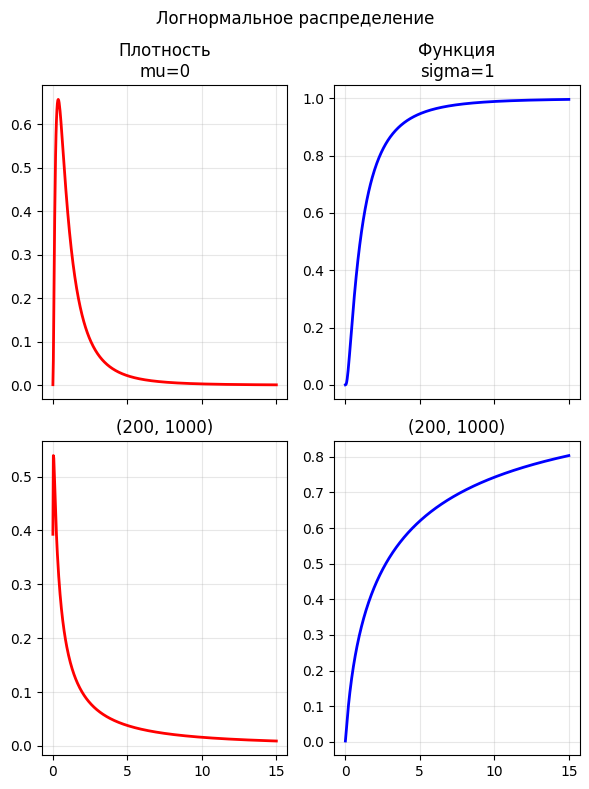

In [116]:
from scipy.stats import lognorm

x = np.linspace(0.01, 15, 500)

params = [(0, 1), (1, 2)]

fig, axes = plt.subplots(len(params), 2, figsize=(6, 8), sharex=True)
row_num = 0
for mu, sigma in params:
    pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu)) # Плотность вероятности
    cdf = lognorm.cdf(x, s=sigma, scale=np.exp(mu)) # Функция распределения
    draw_plot(x, df1, df2, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        print(f"p-value: {lognorm.ppf(p, sigma, np.exp(mu))} при df1={df1}")

axes[0, 0].set_title(f"Плотность\nmu={params[0][0]}")
axes[0, 1].set_title(f"Функция\nsigma={params[0][1]}")
fig.suptitle("Логнормальное распределение")
fig.tight_layout()

#### Нормальное распределение

p-value: 3.6022244792791573 при df1=200
p-value: 5.180251602233013 при df1=200
p-value: 10.240473656312131 при df1=200
p-value: 13.976021199117996 при df1=200
p-value: 27.835006662437703 при df1=200
p-value: 105.86730070562277 при df1=200


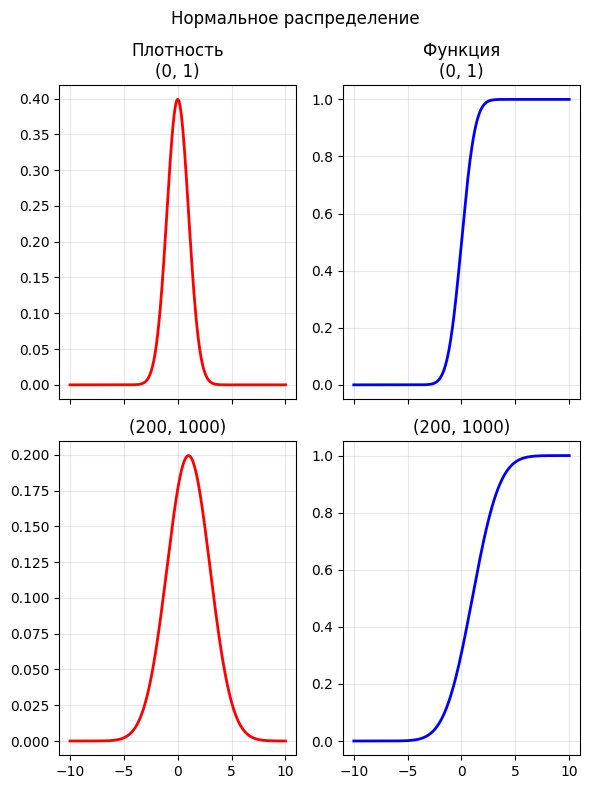

In [117]:
from scipy.stats import norm

x = np.linspace(-10, 10, 500)

params = [(0, 1), (1, 2)]

fig, axes = plt.subplots(len(params), 2, figsize=(6, 8), sharex=True)
row_num = 0
for mu, sigma in params:
    pdf = norm.pdf(x, loc=mu, scale=sigma) # Плотность вероятности
    cdf = norm.cdf(x, loc=mu, scale=sigma) # Функция распределения
    draw_plot(x, df1, df2, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        print(f"p-value: {lognorm.ppf(p, sigma, mu)} при df1={df1}")

axes[0, 0].set_title(f"Плотность\n{params[0]}")
axes[0, 1].set_title(f"Функция\n{params[0]}")
fig.suptitle("Нормальное распределение")
fig.tight_layout()